<a href="https://colab.research.google.com/github/omkar234960/1st-_repo/blob/main/Rainfall_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xg
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import confusion_matrix, accuracy_score,f1_score,precision_score,recall_score,classification_report
from sklearn.model_selection import RandomizedSearchCV


In [208]:
df= pd.read_csv('Rainfall.csv')

In [209]:
df

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...,...
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [211]:
df.columns = df.columns.str.replace(' ', '_')

In [212]:
df.columns

Index(['day', 'pressure_', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity_', 'cloud_', 'rainfall', 'sunshine', '_________winddirection',
       'windspeed'],
      dtype='object')

In [213]:
df.columns = df.columns.str.replace('_','New')

In [214]:
df.columns

Index(['day', 'pressureNew', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidityNew', 'cloudNew', 'rainfall', 'sunshine',
       'NewNewNewNewNewNewNewNewNewwinddirection', 'windspeed'],
      dtype='object')

In [215]:
df.columns = df.columns.str.replace('New','')

In [216]:
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [217]:
df.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [218]:
df.isnull().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [219]:
df['winddirection'] = df['winddirection'].fillna(df['winddirection'].median())

In [220]:
df['windspeed'] = df['windspeed'].fillna(df['windspeed'].mean())

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  366 non-null    float64
 11  windspeed      366 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [222]:
df['rainfall'].value_counts()

,count
rainfall,
yes,249
no,117


In [223]:
df['rainfall'] =df['rainfall'].replace({'yes':1, 'no':0})

/tmp/ipykernel_483/4216544905.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rainfall'] =df['rainfall'].replace({'yes':1, 'no':0})


In [224]:
df['rainfall']

,rainfall
0,1
1,1
2,1
3,1
4,1
...,...
361,1
362,1
363,1
364,1


In [225]:
corr_arr = df.corr()

In [226]:
corr_arr

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
day,1.000000,0.044638,-0.017045,-0.014100,-0.009241,-0.051521,-0.118652,-0.113152,0.010339,0.108927,0.042970,-0.031880
pressure,0.044638,1.000000,-0.829088,-0.851780,-0.839851,-0.860232,-0.274907,0.005621,-0.089275,-0.198171,-0.659693,0.373238
maxtemp,-0.017045,-0.829088,1.000000,0.986193,0.961534,0.899829,0.021882,-0.289765,-0.101003,0.507416,0.627718,-0.441841
temparature,-0.014100,-0.851780,0.986193,1.000000,0.990187,0.936866,0.092030,-0.205895,-0.037360,0.420545,0.647340,-0.393401
mintemp,-0.009241,-0.839851,0.961534,0.990187,1.000000,0.944515,0.139040,-0.156097,-0.007697,0.368288,0.631879,-0.358780
dewpoint,-0.051521,-0.860232,0.899829,0.936866,0.944515,1.000000,0.425282,0.044635,0.139916,0.185234,0.626273,-0.377963
humidity,-0.118652,-0.274907,0.021882,0.092030,0.139040,0.425282,1.000000,0.655493,0.489623,-0.563579,0.100558,-0.076578
cloud,-0.113152,0.005621,-0.289765,-0.205895,-0.156097,0.044635,0.655493,1.000000,0.625766,-0.848334,-0.076520,0.258354
rainfall,0.010339,-0.089275,-0.101003,-0.037360,-0.007697,0.139916,0.489623,0.625766,1.000000,-0.552519,-0.013927,0.154389
sunshine,0.108927,-0.198171,0.507416,0.420545,0.368288,0.185234,-0.563579,-0.848334,-0.552519,1.000000,0.252553,-0.298777


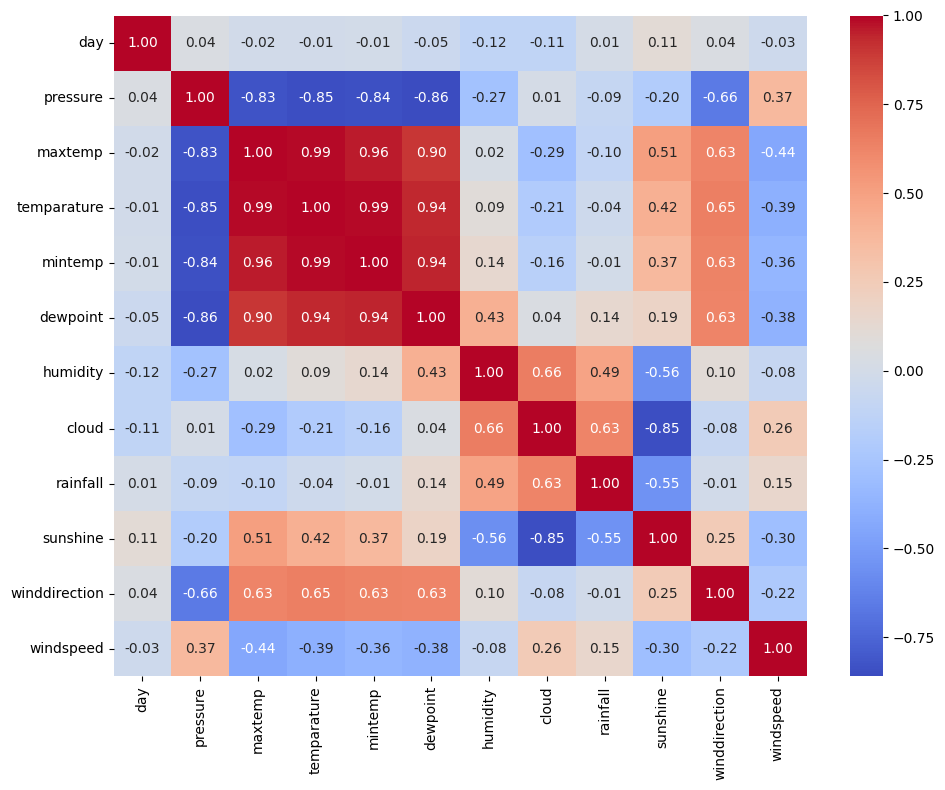

In [227]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.show()

In [228]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [229]:
vif_data = pd.DataFrame()
vif_data["Feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)
                   for i in range(df.shape[1])]

In [230]:
print(vif_data)

          Feature          VIF
0             day     4.479621
1        pressure  1697.006973
2         maxtemp  1978.740204
3     temparature  7415.022656
4         mintemp  1561.782755
5        dewpoint  1881.887440
6        humidity  1231.989249
7           cloud    58.090619
8        rainfall     5.520973
9        sunshine    13.058209
10  winddirection     4.743633
11      windspeed     8.507900


In [231]:
drop_cols = ['maxtemp','mintemp','day','sunshine']
df.drop(drop_cols,axis=1,inplace=True)

In [232]:
df

,pressure,temparature,dewpoint,humidity,cloud,rainfall,winddirection,windspeed
0,1025.9,18.3,13.1,72,49,1,80.0,26.3
1,1022.0,18.9,15.6,81,83,1,50.0,15.3
2,1019.7,19.3,18.4,95,91,1,40.0,14.2
3,1018.9,20.6,18.8,90,88,1,50.0,16.9
4,1015.9,20.7,19.9,95,81,1,40.0,13.7
...,...,...,...,...,...,...,...,...
361,1022.7,17.7,15.0,84,90,1,30.0,18.4
362,1026.6,17.3,12.8,75,85,1,20.0,25.9
363,1025.9,17.7,13.3,75,78,1,70.0,33.4
364,1025.3,17.3,13.3,78,86,1,20.0,20.9


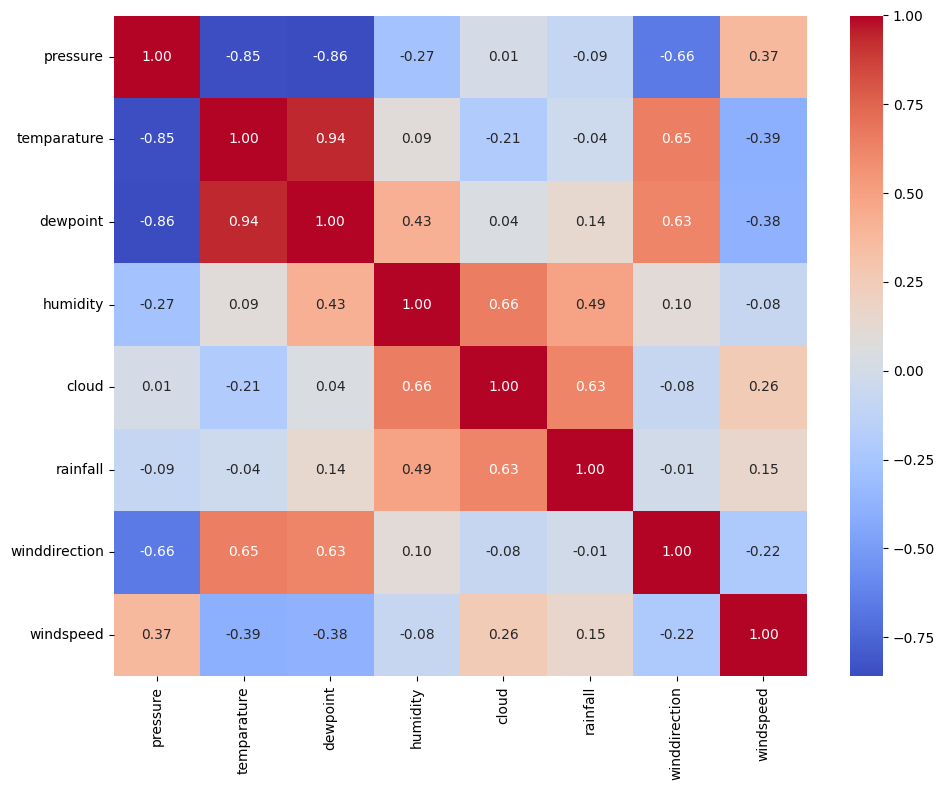

In [233]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.show()

In [234]:
df.drop("dewpoint",axis = 1,inplace = True)

In [235]:
df.columns

Index(['pressure', 'temparature', 'humidity', 'cloud', 'rainfall',
       'winddirection', 'windspeed'],
      dtype='object')

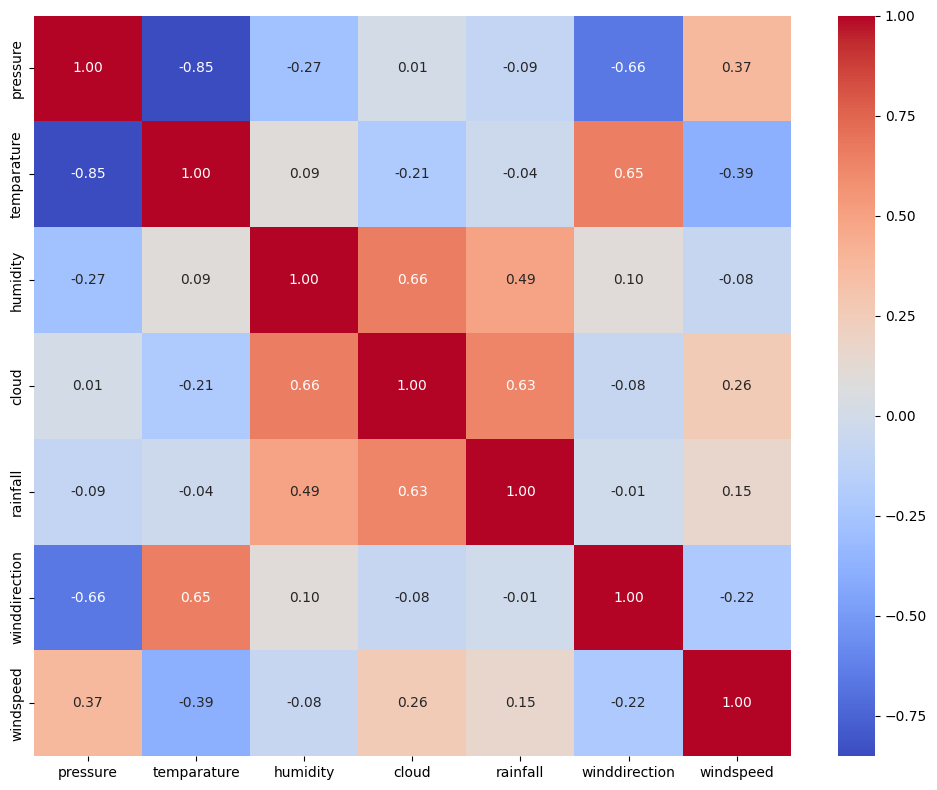

In [236]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.show()

In [237]:
df.columns

Index(['pressure', 'temparature', 'humidity', 'cloud', 'rainfall',
       'winddirection', 'windspeed'],
      dtype='object')

In [238]:
X = df.copy()

In [239]:
X

,pressure,temparature,humidity,cloud,rainfall,winddirection,windspeed
0,1025.9,18.3,72,49,1,80.0,26.3
1,1022.0,18.9,81,83,1,50.0,15.3
2,1019.7,19.3,95,91,1,40.0,14.2
3,1018.9,20.6,90,88,1,50.0,16.9
4,1015.9,20.7,95,81,1,40.0,13.7
...,...,...,...,...,...,...,...
361,1022.7,17.7,84,90,1,30.0,18.4
362,1026.6,17.3,75,85,1,20.0,25.9
363,1025.9,17.7,75,78,1,70.0,33.4
364,1025.3,17.3,78,86,1,20.0,20.9


In [240]:
x = df.drop('rainfall',axis=1)
y= df['rainfall']

In [241]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [242]:
x_scaled

array([[ 1.89780887, -0.96838378, -0.81379523, -1.01654717, -0.26277756,
         0.47430166],
       [ 1.2890053 , -0.86171925,  0.08184175,  0.54536331, -0.63080021,
        -0.62108008],
       [ 0.92996729, -0.79060956,  1.47505483,  0.91287166, -0.75347442,
        -0.73061825],
       ...,
       [ 1.89780887, -1.07504831, -0.51524957,  0.31567059, -0.38545177,
         1.18132078],
       [ 1.80414679, -1.146158  , -0.21670391,  0.68317894, -0.99882286,
        -0.0634312 ],
       [ 1.97586061, -1.05727089, -0.61476479, -0.23559193, -0.99882286,
         0.17556118]])

In [243]:
rus = RandomUnderSampler(random_state=42)
x_rus,y_rus=rus.fit_resample(x_scaled, y)

In [244]:
ros = RandomOverSampler(random_state=42)
x_ros,y_ros=ros.fit_resample(x_scaled,y)

In [245]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x_scaled,y)

In [246]:
x_train , x_test , y_train , y_test = train_test_split(x_scaled , y ,test_size=0.3,random_state=42)

In [247]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 10, None],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.5, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42
)

In [248]:
random_search.fit(x_scaled,y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END learning_rate=0.1, max_depth=5, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.2s


...

[CV] END learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=150, subsample=0.5; total time=   0.1s
[CV] END learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=150, subsample=0.5; total time=   0.0s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

[CV] END learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=150, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=150, subsample=0.5; total time=   0.0s
[CV] END learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=150, subsample=0.5; total time=   0.0s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:37:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2],
                                        'max_depth': [3, 5, 10, None],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 100, 150, 200],
                                        'subsample': [0.5, 0.8, 1.0]},
                   random_state=42, verbose=2)

In [249]:
result_df = pd.DataFrame(random_search.cv_results_)

In [250]:
result_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.109440,0.036168,0.007605,0.002604,0.8,100,3,5,0.10,"{'subsample': 0.8, 'n_estimators': 100, 'min_c...",0.810811,0.712329,0.739726,0.780822,0.767123,0.762162,0.033842,9
1,0.090627,0.079995,0.006679,0.002366,1.0,50,1,3,0.10,"{'subsample': 1.0, 'n_estimators': 50, 'min_ch...",0.810811,0.726027,0.835616,0.767123,0.739726,0.775861,0.041612,7
2,0.112609,0.021274,0.006348,0.001247,0.5,150,3,5,0.01,"{'subsample': 0.5, 'n_estimators': 150, 'min_c...",0.851351,0.753425,0.876712,0.767123,0.808219,0.811366,0.047315,2
3,0.131076,0.053161,0.007002,0.003085,0.5,150,3,5,0.05,"{'subsample': 0.5, 'n_estimators': 150, 'min_c...",0.837838,0.712329,0.863014,0.794521,0.780822,0.797705,0.051885,6
4,0.048825,0.019908,0.002893,0.000455,0.5,200,3,3,0.15,"{'subsample': 0.5, 'n_estimators': 200, 'min_c...",0.770270,0.698630,0.767123,0.739726,0.780822,0.751314,0.029631,10
5,0.030892,0.001350,0.002754,0.000449,1.0,100,5,5,0.01,"{'subsample': 1.0, 'n_estimators': 100, 'min_c...",0.851351,0.726027,0.876712,0.767123,0.808219,0.805887,0.054715,4
6,0.024731,0.002843,0.002468,0.000044,0.5,100,5,5,0.01,"{'subsample': 0.5, 'n_estimators': 100, 'min_c...",0.851351,0.739726,0.904110,0.767123,0.835616,0.819585,0.059229,1
7,0.017935,0.000955,0.002569,0.000250,0.8,50,1,3,0.05,"{'subsample': 0.8, 'n_estimators': 50, 'min_ch...",0.864865,0.726027,0.890411,0.780822,0.767123,0.805850,0.061856,5
8,0.028733,0.003799,0.002465,0.000036,0.8,100,1,3,0.10,"{'subsample': 0.8, 'n_estimators': 100, 'min_c...",0.824324,0.698630,0.794521,0.794521,0.753425,0.773084,0.043530,8
9,0.035716,0.010609,0.002625,0.000167,0.5,150,5,10,0.10,"{'subsample': 0.5, 'n_estimators': 150, 'min_c...",0.851351,0.739726,0.863014,0.821918,0.780822,0.811366,0.045701,2


In [251]:
xg_final_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_estimators = 150,
    min_child_weight=3,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.5
)

In [252]:
xg_final_model.fit(x_train , y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [253]:
y_pred = xg_final_model.predict(x_test)

In [254]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.7727272727272727
[[17 17]
 [ 8 68]]


In [255]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.68      0.50      0.58        34
           1       0.80      0.89      0.84        76

    accuracy                           0.77       110
   macro avg       0.74      0.70      0.71       110
weighted avg       0.76      0.77      0.76       110



In [256]:
x_rus_train , x_rus_test , y_rus_train , y_rus_split = train_test_split(x_rus , y_rus , test_size = 0.3,random_state =42)

In [257]:
x_ros_train , x_ros_test , y_ros_train , y_ros_split = train_test_split(x_ros , y_ros , test_size = 0.3,random_state =42)

In [258]:
x_smote_train , x_smote_test , y_smote_train , y_smote_split = train_test_split(X_resampled , y_resampled , test_size = 0.3,random_state =42)

In [259]:
xg_final_model.fit(x_rus_train,y_rus_train)
y_rus = xg_final_model.predict(x_rus_test)


In [260]:
print(classification_report(y_rus,y_rus_split))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81        34
           1       0.82      0.84      0.83        37

    accuracy                           0.82        71
   macro avg       0.82      0.82      0.82        71
weighted avg       0.82      0.82      0.82        71



In [261]:
xg_final_model.fit(x_ros_train,y_ros_train)
y_ros = xg_final_model.predict(x_ros_test)


In [262]:
print(classification_report(y_ros,y_ros_split))

              precision    recall  f1-score   support

           0       0.64      0.86      0.73        59
           1       0.89      0.68      0.77        91

    accuracy                           0.75       150
   macro avg       0.76      0.77      0.75       150
weighted avg       0.79      0.75      0.76       150



In [263]:
xg_final_model.fit(x_smote_train,y_smote_train)
y_smote = xg_final_model.predict(x_smote_test)

In [264]:
print(classification_report(y_smote,y_smote_split))

              precision    recall  f1-score   support

           0       0.69      0.86      0.76        64
           1       0.87      0.71      0.78        86

    accuracy                           0.77       150
   macro avg       0.78      0.78      0.77       150
weighted avg       0.79      0.77      0.77       150

